In [62]:
!python -m pip install opencv-python


In [63]:
!python -m pip install tensorflow_hub


In [64]:
!python -m pip install setuptools tensorflow_hub -q

import numpy as np
import cv2
import PIL.Image as Image
import os

import matplotlib.pylab as plt
import tensorflow as tf
import sys, subprocess

import pkg_resources
import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential


In [65]:
!python -m pip install "setuptools<81"


In [98]:
INPUT_SHAPE= (224, 224)

classifier = hub.KerasLayer(
    "https://tfhub.dev/google/imagenet/mobilenet_v2_140_224/classification/4",
    input_shape=INPUT_SHAPE + (3,)
)

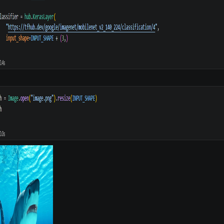

In [148]:
sh = Image.open("abc.png").resize(INPUT_SHAPE)
sh


In [149]:
sh = np.array(sh) / 255.0


In [151]:
sh.shape

(224, 224, 4)

In [70]:
sh

array([[[0.04705882, 0.77647059, 0.82745098],
        [0.03921569, 0.77647059, 0.85098039],
        [0.05882353, 0.79607843, 0.90196078],
        ...,
        [0.36862745, 0.95294118, 0.98823529],
        [0.27843137, 0.90196078, 0.9372549 ],
        [0.27058824, 0.87843137, 0.91372549]],

       [[0.08627451, 0.81568627, 0.8745098 ],
        [0.05490196, 0.78823529, 0.8627451 ],
        [0.0745098 , 0.81568627, 0.90196078],
        ...,
        [0.4745098 , 0.98039216, 0.98431373],
        [0.45098039, 0.94901961, 0.96078431],
        [0.51764706, 0.98823529, 0.99607843]],

       [[0.13333333, 0.8627451 , 0.92941176],
        [0.13333333, 0.86666667, 0.93333333],
        [0.10196078, 0.84313725, 0.91372549],
        ...,
        [0.36862745, 0.88627451, 0.89411765],
        [0.44705882, 0.94117647, 0.95686275],
        [0.41960784, 0.9372549 , 0.94901961]],

       ...,

       [[0.        , 0.43137255, 0.74901961],
        [0.        , 0.43137255, 0.74901961],
        [0.        , 0

In [71]:
result = classifier(sh[np.newaxis, ...])
result.shape

TensorShape([1, 1001])

In [72]:

result

<tf.Tensor: shape=(1, 1001), dtype=float32, numpy=
array([[ 0.12004501,  0.91006273,  0.4350361 , ..., -0.323817  ,
        -0.06061633,  0.83545995]], shape=(1, 1001), dtype=float32)>

In [73]:
index = np.argmax(result)

In [74]:
index

np.int64(4)

In [75]:
image_labels = []
with open("lab.txt", "r") as f:
    image_labels = f.read().splitlines()
image_labels[:5]

['background', 'tench', 'goldfish', 'great white shark', 'tiger shark']

In [76]:
image_labels[index]

'tiger shark'

In [77]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)

In [78]:
data_dir

'.\\datasets\\flower_photos'

In [79]:
import pathlib
data_dir = pathlib.Path(data_dir)
if (data_dir / "flower_photos").is_dir():
    data_dir = data_dir / "flower_photos"
data_dir

WindowsPath('datasets/flower_photos/flower_photos')

In [80]:
list(data_dir.glob('*/*.jpg'))[:5]

[WindowsPath('datasets/flower_photos/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172636503_21bededa75_n.jpg')]

In [81]:

image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [82]:

roses = list(data_dir.glob('roses/*'))
roses[:5]

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

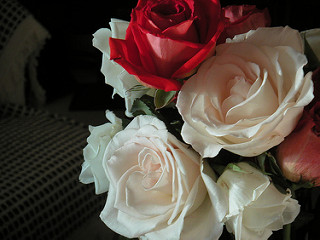

In [83]:
import PIL
PIL.Image.open(str(roses[1]))

In [84]:

flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [85]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [86]:

img = cv2.imread(str(flowers_images_dict['roses'][0]))


In [87]:

img.shape

(240, 179, 3)

In [88]:

cv2.resize(img,(224,224)).shape

(224, 224, 3)

In [89]:

X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(224,224))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [90]:
X = np.array(X)
y = np.array(y)

In [91]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)


In [92]:

X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [102]:

X[0].shape

(224, 224, 3)

In [105]:
INPUT_SHAPE+(3,)

(224, 224, 3)

In [106]:

x0_resized = cv2.resize(X[0], INPUT_SHAPE)
x1_resized = cv2.resize(X[1], INPUT_SHAPE)
x2_resized = cv2.resize(X[2], INPUT_SHAPE)

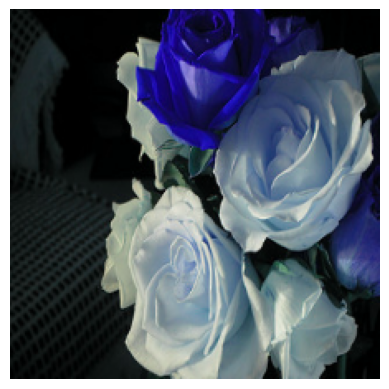

In [118]:

plt.axis('off')
plt.imshow(X[1])

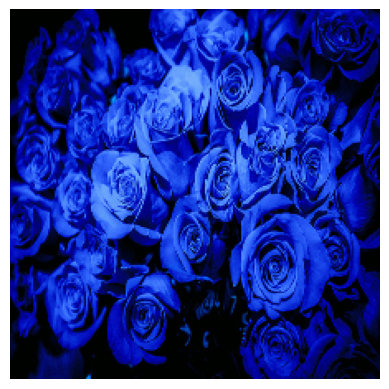

In [119]:

plt.axis('off')
plt.imshow(X[2])

In [112]:
predicted = classifier(np.asarray([x0_resized, x1_resized, x2_resized], dtype=np.float32) / 255.0, training=False)
predicted = np.argmax(predicted, axis=1)
predicted

array([585, 729, 114])

In [120]:

image_labels[585]

'hair slide'

In [121]:
image_labels[729]

'plastic bag'

In [122]:
image_labels[114]

'snail'

In [123]:
feature_extractor_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

pretrained_model_without_top_layer = hub.KerasLayer(
    feature_extractor_model, input_shape=(224, 224, 3), trainable=False)

In [125]:
num_of_flowers = 5

model = tf.keras.Sequential([
    tf.keras.layers.Lambda(lambda x: pretrained_model_without_top_layer(x)),
    tf.keras.layers.Dense(num_of_flowers)
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [126]:

model.compile(
  optimizer="adam",
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['acc'])

model.fit(X_train_scaled, y_train, epochs=5)

Epoch 1/5



86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 146ms/step - acc: 0.6995 - loss: 0.8031
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 156ms/step - acc: 0.8601 - loss: 0.4108
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 150ms/step - acc: 0.8983 - loss: 0.3218
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 150ms/step - acc: 0.9168 - loss: 0.2649
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 148ms/step - acc: 0.9284 - loss: 0.2329


In [127]:

model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 145ms/step - acc: 0.8682 - loss: 0.3670


[0.36695370078086853, 0.8681917190551758]

image 0: actual=roses, predicted=roses
image 1: actual=roses, predicted=roses
image 2: actual=roses, predicted=roses


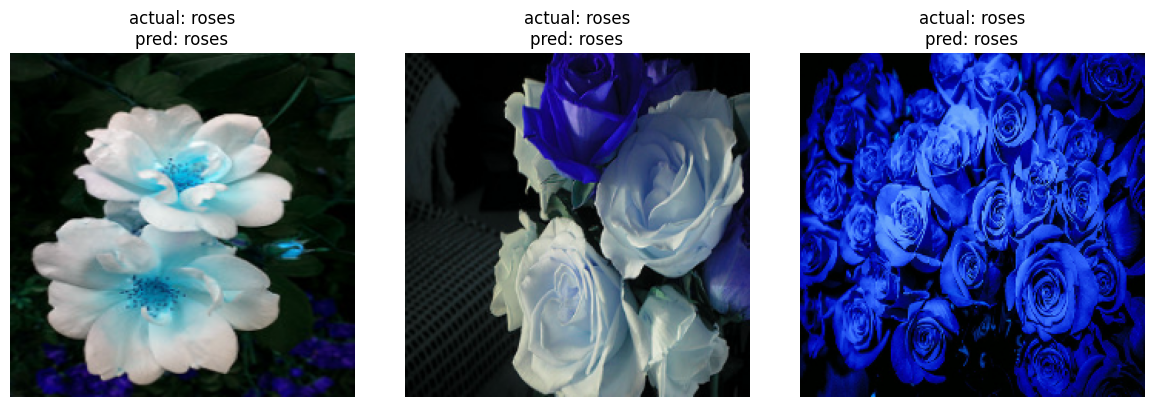

In [136]:
# test the trained model on the same sample images
flower_names = {value: key for key, value in flowers_labels_dict.items()}
sample_indices = [0, 1, 2]
sample_images = np.asarray([X[i] for i in sample_indices], dtype=np.float32) / 255.0

logits = model(sample_images, training=False)
predicted = tf.argmax(logits, axis=1).numpy()

for idx, pred in zip(sample_indices, predicted):
    actual_label = flower_names[y[idx]]
    predicted_label = flower_names[pred]
    print(f"image {idx}: actual={actual_label}, predicted={predicted_label}")

fig, axes = plt.subplots(1, len(sample_indices), figsize=(12, 4))
for ax, idx, pred in zip(axes, sample_indices, predicted):
    ax.imshow(X[idx].astype("uint8"))
    ax.set_title(f"actual: {flower_names[y[idx]]}\npred: {flower_names[pred]}")
    ax.axis("off")
plt.tight_layout()

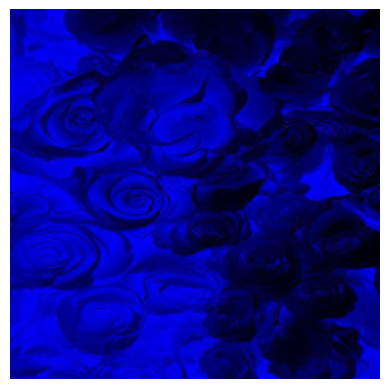

In [137]:
#one example from tulips class
tulip_image = X[flowers_labels_dict['tulips']]
plt.axis('off')
plt.imshow(tulip_image)


In [138]:
#now predict the label for this image using the trained model
tulip_image_resized = cv2.resize(tulip_image, INPUT_SHAPE)
logits = model(np.asarray([tulip_image_resized], dtype=np.float32) / 255.0, training=False)
predicted = tf.argmax(logits, axis=1).numpy()


In [ ]:
predicted_class = np.argmax(result[0], axis=-1)
predicted_class #['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips'


np.int64(4)